##Data Preprocessing

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("PromptCloudHQ/amazon-reviews-unlocked-mobile-phones")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'amazon-reviews-unlocked-mobile-phones' dataset.
Path to dataset files: /kaggle/input/amazon-reviews-unlocked-mobile-phones


In [3]:
import pandas as pd
import os

print(os.listdir(path))
df = pd.read_csv(os.path.join(path, "Amazon_Unlocked_Mobile.csv"))
df.head()

['Amazon_Unlocked_Mobile.csv']


,Product Name,Brand Name,Price,Rating,Reviews,Review Votes
0,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,I feel so LUCKY to have found this used (phone...,1.0
1,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,"nice phone, nice up grade from my pantach revu...",0.0
2,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,Very pleased,0.0
3,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,It works good but it goes slow sometimes but i...,0.0
4,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,Great phone to replace my lost phone. The only...,0.0


In [4]:
df.shape

(413840, 6)

In [5]:
# Renaming columns
df.columns = ['product_name', 'brand_name', 'price', 'rating', 'reviews', 'review_votes']

print(df.dtypes)
print("---"*6)
print(df.isna().sum())

product_name     object
brand_name       object
price           float64
rating            int64
reviews          object
review_votes    float64
dtype: object
------------------
product_name        0
brand_name      65171
price            5933
rating              0
reviews            70
review_votes    12296
dtype: int64


In [6]:
# Fill brand nulls with "Unknown"
df['brand_name'] = df['brand_name'].fillna('Unknown')

# Fill review_votes nulls with 0
df['review_votes'] = df['review_votes'].fillna(0)

# Drop rows where price or reviews are missing
df.dropna(subset=['price', 'reviews'], inplace=True)

print(df.shape)
print(df.isnull().sum())

(407840, 6)
product_name    0
brand_name      0
price           0
rating          0
reviews         0
review_votes    0
dtype: int64


In [7]:
# Create a reccomendation column(Target columns)
df['recommended'] = (df['rating'] >= 4).astype(int)

# Check the distribution
print(df['recommended'].value_counts())
print(df['recommended'].value_counts(normalize=True).mul(100).round(1))

recommended
1    281507
0    126333
Name: count, dtype: int64
recommended
1    69.0
0    31.0
Name: proportion, dtype: float64


##Feature Engineering

In [8]:
!pip install vaderSentiment -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.2 MB/s eta 0:00:00


VADER (Valence Aware Dictionary and sEntiment Reasoner) is a rule-based NLP tool that reads a piece of text and returns a score telling you how positive or negative it is.

In [9]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [10]:
analyzer = SentimentIntensityAnalyzer()

# Apply to every review in the dataset
df['sentiment_score'] = df['reviews'].astype(str).apply(
    lambda x: analyzer.polarity_scores(x)['compound']
) # lambda x just means `for each review x, run this function`

print(df['sentiment_score'].describe())

count    407840.000000
mean          0.375918
std           0.510966
min          -0.998200
25%           0.000000
50%           0.555400
75%           0.799000
max           0.999900
Name: sentiment_score, dtype: float64


In [11]:
# Review Length
df['review_length'] = df['reviews'].astype(str).apply(len)

print(df['review_length'].describe())

count    407840.000000
mean        216.610269
std         463.561452
min           1.000000
25%          27.000000
50%          93.000000
75%         223.000000
max       29419.000000
Name: review_length, dtype: float64


The idea here is that longer reviews tend to be more detailed and considered. Someone who writes 3 paragraphs about a phone is more engaged than someone who writes "good phone". This can be a signal the model learns from.

In [12]:
# Brand Average Rating and Brand Review Count
brand_stats = df.groupby('brand_name')['rating'].agg(
    brand_avg_rating='mean',
    brand_review_count='count'
).reset_index()

df = df.merge(brand_stats, on='brand_name', how='left')

print(df[['brand_name', 'brand_avg_rating', 'brand_review_count']].head(10))

  brand_name  brand_avg_rating  brand_review_count
0    Samsung          3.963771               64783
1    Samsung          3.963771               64783
2    Samsung          3.963771               64783
3    Samsung          3.963771               64783
4    Samsung          3.963771               64783
5    Samsung          3.963771               64783
6    Samsung          3.963771               64783
7    Samsung          3.963771               64783
8    Samsung          3.963771               64783
9    Samsung          3.963771               64783


This captures brand reputation. The idea is:

- A Samsung product is more likely to be recommended than an unknown brand
- A brand with 50,000 reviews carries more weight than one with 3

In [13]:
# Price tier
df['price_tier'] = pd.cut(
    df['price'],
    bins=[0, 100, 300, 600, 99999],
    labels=[0, 1, 2, 3]
).astype(int)

# 0 = Budget (< $100)
# 1 = Mid-range ($100 - $300)
# 2 = Premium ($300 - $600)
# 3 = Ultra-premium (> $600)

print(df['price_tier'].value_counts().sort_index())

price_tier
0    151173
1    170756
2     62087
3     23824
Name: count, dtype: int64


##Model Training

In [14]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             roc_auc_score)


In [15]:
features = ['price', 'sentiment_score', 'review_length',
            'review_votes', 'brand_avg_rating', 'brand_review_count', 'price_tier']

X = df[features]
y = df['recommended']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [16]:
# Calculate scale_pos_weight to handle 69/31 imbalance
# Formula: number of 0s / number of 1s
scale = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale:.4f}")

model = XGBClassifier(
    n_estimators=100,        # number of trees
    max_depth=6,             # how deep each tree grows
    learning_rate=0.1,       # how fast the model learns
    scale_pos_weight=scale,  # handles class imbalance
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train, y_train)
print("Model trained successfully")

scale_pos_weight: 0.4497
Model trained successfully


In [17]:
# Model Evaluation
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]  # recommendation likelihood score

print(classification_report(y_test, y_pred))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")

              precision    recall  f1-score   support

           0       0.69      0.86      0.76     25129
           1       0.93      0.83      0.88     56439

    accuracy                           0.84     81568
   macro avg       0.81      0.84      0.82     81568
weighted avg       0.85      0.84      0.84     81568

AUC-ROC: 0.9191


##Explainability with SHAP (SHapley Additive exPlanations)


SHAP assigns each feature a value that represents how much it pushed the prediction higher or lower compared to the average prediction. Positive SHAP value means the feature pushed toward recommended, negative means it pushed away.

For example on a single product:
Base prediction:        0.65 (average)
+ sentiment_score:     +0.15 (positive review pushed it up)
+ brand_avg_rating:    +0.10 (strong brand pushed it up)
+ price:               -0.08 (expensive pushed it down)

Final prediction:       0.82 (recommended)

In [18]:
!pip install shap -q


In [19]:
import shap
import matplotlib.pyplot as plt
import numpy as np

In [20]:
# Create the explainer
explainer = shap.TreeExplainer(model)

# Split the data into a sample of 1000 values and get the SHAP values.
X_sample = X_test.sample(1000, random_state=42)
shap_values = explainer.shap_values(X_sample)

print("SHAP values shape:", shap_values.shape)


SHAP values shape: (1000, 7)


###Summary Plot (Global Explainability)

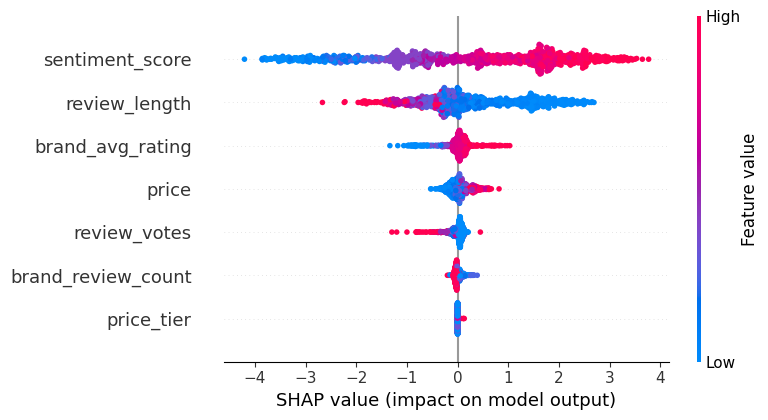

<Figure size 640x480 with 0 Axes>

In [21]:
shap.summary_plot(shap_values, X_sample, feature_names=features)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

Sentiment score dominates. Highly positive reviews pushed recommendation likelihood up sharply — negative ones pulled it down just as hard. Review length landed second, though the direction is counterintuitive: shorter reviews actually correlated with higher scores, not longer ones. Brand average rating tracked predictably with recommendation likelihood. Price, review votes, and brand review count had some effect but not much. Price tier was nearly irrelevant. What a customer writes about a product, it turns out, matters more than what the product costs.

###Feature Importance

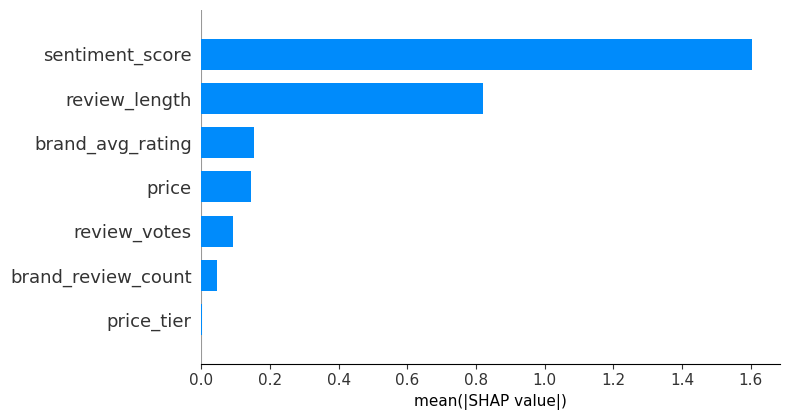

In [22]:
plt.close('all')

fig, ax = plt.subplots(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample,
                  feature_names=features,
                  plot_type='bar',
                  show=False)
plt.xlabel('mean(|SHAP value|)', fontsize=11)
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

The bar chart ranks each feature by its average impact across all 1000 predictions. Sentiment score and review length dominate, everything else barely registers. The model is largely making decisions based on how a review reads, not what the product costs or which brand made it.


Index: 424
Recommendation likelihood: 0.9961
price                  1157.00000
sentiment_score           0.84810
review_length            26.00000
review_votes              0.00000
brand_avg_rating          3.92463
brand_review_count    58087.00000
price_tier                3.00000
Name: 70683, dtype: float64
Brand: Apple


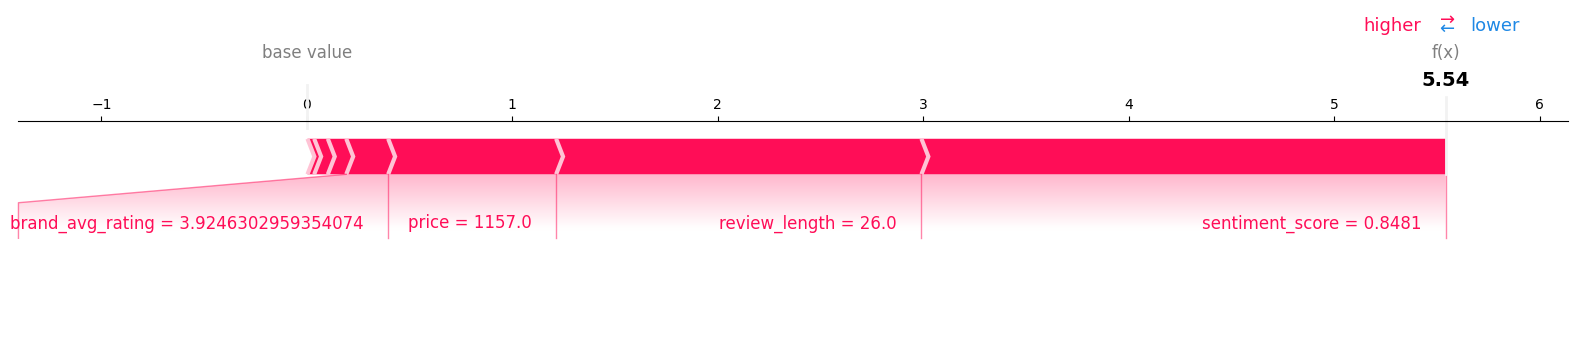

<Figure size 640x480 with 0 Axes>

In [23]:
# Find a row where model predicts recommended with high confidence
y_prob_sample = model.predict_proba(X_sample)[:, 1]

# Pick one with high recommendation likelihood
best_idx = y_prob_sample.argmax()
print(f"Index: {best_idx}")
print(f"Recommendation likelihood: {y_prob_sample[best_idx]:.4f}")
print(X_sample.iloc[best_idx])
print(f"Brand: {df.loc[X_sample.iloc[best_idx].name, 'brand_name']}")

# Now plot it
shap.force_plot(
    explainer.expected_value,
    shap_values[best_idx],
    X_sample.iloc[[best_idx]],
    feature_names=features,
    matplotlib=True
)
plt.savefig('shap_force.png', dpi=150, bbox_inches='tight')
plt.show()

This $1,157 phone from a well-rated brand received a short but very positive review — the model recommends it with 99.6% confidence.

Index: 769
Recommendation likelihood: 0.4978
price                   339.990000
sentiment_score           0.475400
review_length            93.000000
review_votes              3.000000
brand_avg_rating          3.963771
brand_review_count    64783.000000
price_tier                2.000000
Name: 353919, dtype: float64
Brand: Samsung


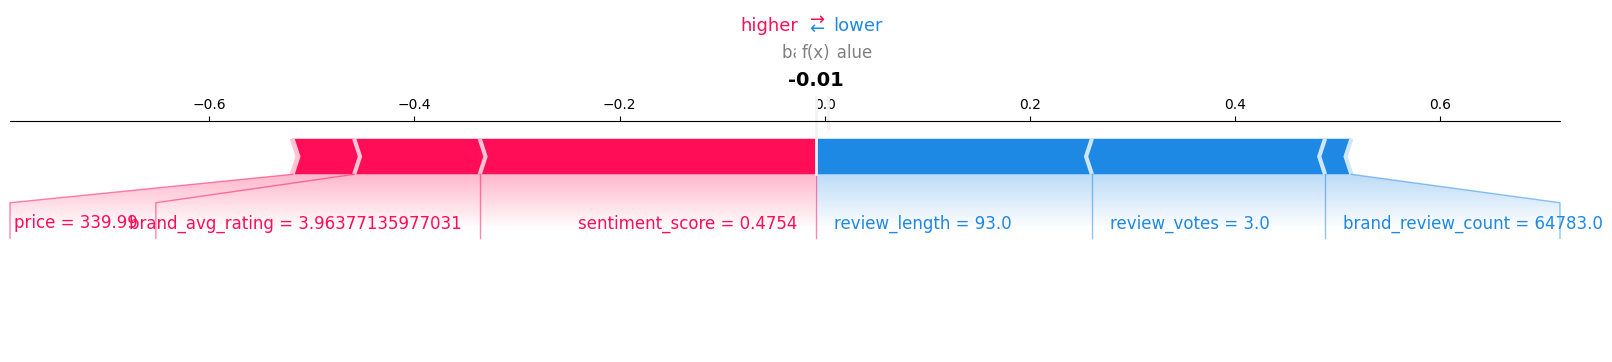

<Figure size 640x480 with 0 Axes>

In [24]:
# Find samples where model is uncertain - probability close to 0.5
uncertainty_scores = np.abs(y_prob_sample - 0.5)
mixed_idx = uncertainty_scores.argmin()

print(f"Index: {mixed_idx}")
print(f"Recommendation likelihood: {y_prob_sample[mixed_idx]:.4f}")
print(X_sample.iloc[mixed_idx])
print(f"Brand: {df.loc[X_sample.iloc[mixed_idx].name, 'brand_name']}")

shap.force_plot(
    explainer.expected_value,
    shap_values[mixed_idx],
    X_sample.iloc[[mixed_idx]],
    feature_names=features,
    matplotlib=True
)
plt.savefig('shap_force_mixed.png', dpi=150, bbox_inches='tight')
plt.show()

This is a $340 Samsung phone with decent brand reputation, but the customer's review was lukewarm and barely anyone agreed with it. The model can't make up its mind, and honestly, neither could the reviewer.

##Explainabilty with LIME

In [25]:
!pip install lime -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [26]:
from lime.lime_tabular import LimeTabularExplainer

In [27]:
lime_explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=features,
    class_names=['Not Recommended', 'Recommended'],
    mode='classification'
)

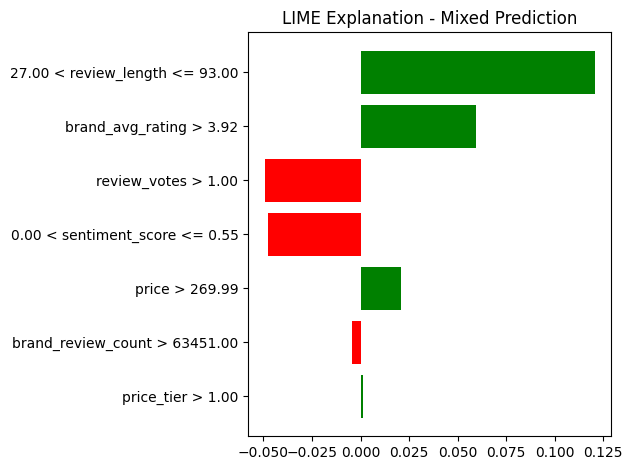

In [28]:
# Using the same mixed sample (index 769)
lime_exp = lime_explainer.explain_instance(
    data_row=X_sample.iloc[mixed_idx].values,
    predict_fn=model.predict_proba,
    num_features=7
)

lime_exp.as_pyplot_figure()
plt.title('LIME Explanation - Mixed Prediction')
plt.tight_layout()
plt.savefig('lime_explanation.png', dpi=150, bbox_inches='tight')
plt.show()

LIME uses conditions rather than exact values — "sentiment between 0 and 0.55" instead of a raw number. Here, medium review length and brand reputation said yes. Lukewarm sentiment and barely-voted reviews said no. The model split the difference at 49.78%, which is about right — nothing about this product screams buy it, but nothing rules it out either.

###Differences Between SHAP and LIME



5 Differences Between LIME and SHAP (based on what we actually saw)
1. How they show feature impact
SHAP showed exact feature values (sentiment_score = 0.4754). LIME showed conditions (0.00 < sentiment_score <= 0.55). SHAP is more precise, LIME is more readable.
2. Scale of the values
SHAP values went up to 1.6 on the bar plot. LIME values maxed out at 0.125. They're measuring impact differently — not directly comparable numbers.
3. Color meaning
SHAP used red/blue. LIME used green/red. Different conventions, same idea — one direction supports the prediction, the other opposes it.
4. Global vs Local
SHAP gave us both a global view (summary plot across 1000 samples) and local (single prediction). LIME only explains one prediction at a time — it has no global view.
5. What they're actually doing internally
SHAP uses game theory to fairly distribute credit among features. LIME creates thousands of slightly modified versions of the input, runs them through the model, and fits a simple linear model to approximate what happened locally. SHAP is mathematically exact, LIME is an approximation.

###Bias and Fairness Analysis

In [29]:
# Add prediction probabilities back to the full test set
X_test_copy = X_test.copy()
X_test_copy['predicted_prob'] = model.predict_proba(X_test)[:, 1]
X_test_copy['predicted'] = model.predict(X_test)
X_test_copy['actual'] = y_test.values

print(X_test_copy.head())

         price  sentiment_score  review_length  review_votes  \
99816    83.73           0.4122            356          23.0   
66135   640.00           0.2500             88           1.0   
389922  244.95           0.9990           3666          34.0   
49509   428.13           0.7351            127           2.0   
276007  139.99          -0.8875            375           1.0   

        brand_avg_rating  brand_review_count  price_tier  predicted_prob  \
99816           3.741465               16872           0        0.247546   
66135           3.924630               58087           3        0.434684   
389922          3.851255               63451           1        0.781698   
49509           3.851255               63451           2        0.712061   
276007          3.851255               63451           1        0.025435   

        predicted  actual  
99816           0       1  
66135           0       1  
389922          1       1  
49509           1       1  
276007          0 

####Bias Check 1 — Price Bias
Do expensive products get recommended more?

In [30]:
# Split into price groups
X_test_copy['price_group'] = pd.cut(
    X_test_copy['price'],
    bins=[0, 100, 300, 600, 99999],
    labels=['Budget', 'Mid-range', 'Premium', 'Ultra-premium']
)

price_bias = X_test_copy.groupby('price_group')['predicted_prob'].mean()
print("Average recommendation likelihood by price group:")
print(price_bias)

Average recommendation likelihood by price group:
price_group
Budget           0.539821
Mid-range        0.616557
Premium          0.679963
Ultra-premium    0.713695
Name: predicted_prob, dtype: float32


/tmp/ipykernel_1227/3323231014.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_bias = X_test_copy.groupby('price_group')['predicted_prob'].mean()


Budget phones averaged 54% recommendation likelihood. Mid-range hit 62%, premium 68%, ultra-premium 71%. The gap is steady and one-directional. Pricier products tend to attract more enthusiastic reviewers, so the model picks that up and runs with it. A $80 phone is already behind before anyone reads a single word about it.

Bias Check 2 - Popularity Bias
Do products from brands with more reviews get recommended more?


In [31]:
# Split brands into popularity groups by review count
X_test_copy['brand_popularity'] = pd.cut(
    X_test_copy['brand_review_count'],
    bins=[0, 500, 5000, 20000, 999999],
    labels=['Unknown', 'Small', 'Mid', 'Large']
)

popularity_bias = X_test_copy.groupby('brand_popularity', observed=False)['predicted_prob'].mean()
print("Average recommendation likelihood by brand size:")
print(popularity_bias)

Average recommendation likelihood by brand size:
brand_popularity
Unknown    0.509918
Small      0.604979
Mid        0.554299
Large      0.625820
Name: predicted_prob, dtype: float32


Unknown brands averaged 51% recommendation likelihood. Large brands averaged 63%. The model picked up on the pattern that bigger brands tend to rate better overall, which statistically holds, but it means a quality product from a small manufacturer gets scored lower before the model even looks at its reviews. The brand name is doing work it probably shouldn't be doing.


####Bias Check 3 — Sentiment Bias
Do products with neutral reviews get unfairly penalized compared to positive ones?


In [32]:
# Split sentiment into groups
X_test_copy['sentiment_group'] = pd.cut(
    X_test_copy['sentiment_score'],
    bins=[-1, -0.05, 0.05, 0.5, 1.0],
    labels=['Negative', 'Neutral', 'Mildly Positive', 'Very Positive']
)

sentiment_bias = X_test_copy.groupby('sentiment_group', observed=False)['predicted_prob'].mean()
print("Average recommendation likelihood by sentiment group:")
print(sentiment_bias)

Average recommendation likelihood by sentiment group:
sentiment_group
Negative           0.074547
Neutral            0.451436
Mildly Positive    0.591029
Very Positive      0.824925
Name: predicted_prob, dtype: float32


Negative reviews averaged 7% recommendation likelihood. Very positive ones averaged 83%. Neutral reviews, the kind where someone says "it works fine, no complaints," only hit 45%. The model treats measured feedback as a weak signal. A product with hundreds of honest, balanced reviews will score lower than one with fewer but more enthusiastic ones. That's a bias worth flagging.


##Exporting Models

In [33]:
"""import joblib

joblib.dump(model, 'recommendation_model.pkl')
joblib.dump(explainer, 'shap_explainer.pkl')"""

"import joblib\n\njoblib.dump(model, 'recommendation_model.pkl')\njoblib.dump(explainer, 'shap_explainer.pkl')"

In [34]:
# A model with the brand names and their ratings and review counts
"""brand_lookup = df.groupby('brand_name')[['brand_avg_rating', 'brand_review_count']].first()
joblib.dump(brand_lookup, 'brand_lookup.pkl')"""

"brand_lookup = df.groupby('brand_name')[['brand_avg_rating', 'brand_review_count']].first()\njoblib.dump(brand_lookup, 'brand_lookup.pkl')"

In [35]:
# Check all plot files are saved
import os
plots = ['shap_summary.png', 'shap_bar.png', 'shap_force.png',
         'shap_force_mixed.png', 'lime_explanation.png']

for p in plots:
    exists = os.path.exists(p)
    print(f"{p}: {'EXISTS' if exists else 'MISSING'}")

shap_summary.png: EXISTS
shap_bar.png: EXISTS
shap_force.png: EXISTS
shap_force_mixed.png: EXISTS
lime_explanation.png: EXISTS


In [36]:
import matplotlib.pyplot as plt
import shap

# Summary plot
plt.close('all')
shap.summary_plot(shap_values, X_sample, feature_names=features, show=False)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.close()

# Force plot - high confidence
plt.close('all')
shap.force_plot(
    explainer.expected_value,
    shap_values[best_idx],
    X_sample.iloc[[best_idx]],
    feature_names=features,
    matplotlib=True,
    show=False
)
plt.savefig('shap_force.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.close()

# Force plot - mixed
plt.close('all')
shap.force_plot(
    explainer.expected_value,
    shap_values[mixed_idx],
    X_sample.iloc[[mixed_idx]],
    feature_names=features,
    matplotlib=True,
    show=False
)
plt.savefig('shap_force_mixed.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.close()

print("All saved")

All saved


In [38]:
import numpy as np

# Save just 500 rows - enough for LIME to understand distributions
np.save('X_train_sample.npy', X_train.sample(500, random_state=42).values)
print("Saved")

Saved
